In [4]:
import json
import pandas as pd
from pathlib import Path
from xgboost import XGBRegressor
import joblib

model = XGBRegressor()

# Path can't open file
#model.load_model("/Users/chloekentebe/enerstasis-electricity-forecaster/xgboost_model/forecast_best_xgboost_model_j12.json")
model = joblib.load("/Users/chloekentebe/enerstasis-electricity-forecaster/xgboost_model/forecast_best_xgboost_model_j12.joblib")
with open("/Users/chloekentebe/enerstasis-electricity-forecaster/xgboost_model/forecast_feature_columns_j12.json", "r") as f:
    feature_columns = json.load(f)

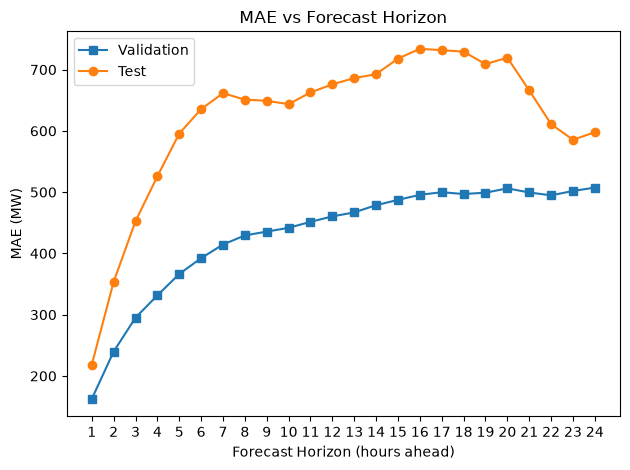

In [21]:
import matplotlib.pyplot as plt
hm = pd.read_csv("/Users/chloekentebe/enerstasis-electricity-forecaster/xgboost_model/horizon_metrics_2.csv")

plt.plot(hm["Horizon"], hm["Validation MAE"], label ="Validation", marker="s")
plt.plot(hm["Horizon"], hm["Test MAE"], label ="Test", marker="o")
plt.title("MAE vs Forecast Horizon")
plt.xlabel("Forecast Horizon (hours ahead)")
plt.xticks(range(1,25))
plt.ylabel("MAE (MW)")
plt.legend()
plt.tight_layout()
plt.show()

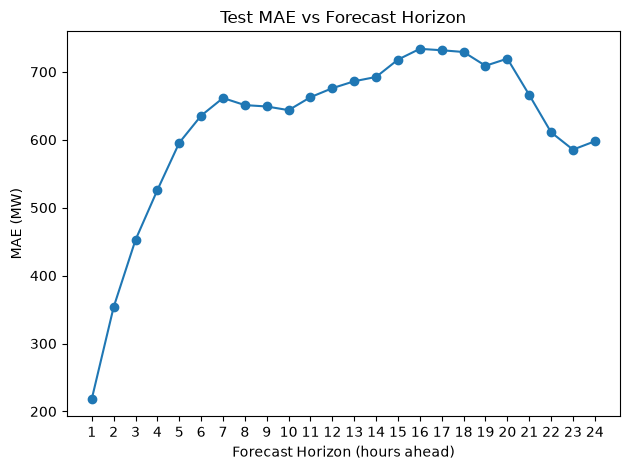

In [27]:
import matplotlib.pyplot as plt
hm = pd.read_csv("/Users/chloekentebe/enerstasis-electricity-forecaster/xgboost_model/horizon_metrics_2.csv")

plt.plot(hm["Horizon"], hm["Test MAE"], label ="Test", marker="o")
plt.title("Test MAE vs Forecast Horizon")
plt.xlabel("Forecast Horizon (hours ahead)")
plt.xticks(range(1,25))
plt.ylabel("MAE (MW)")
plt.tight_layout()
plt.show()

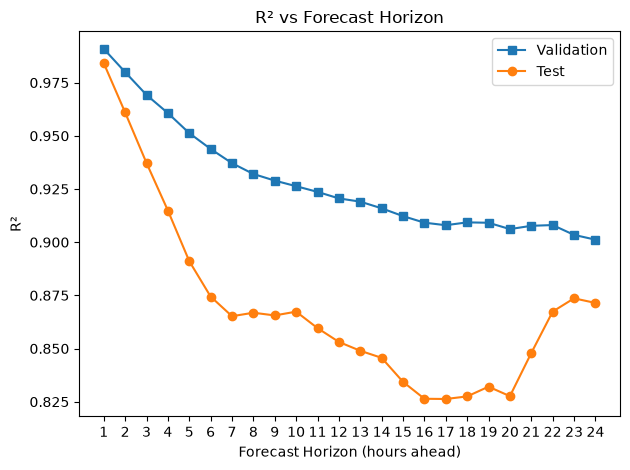

In [24]:
plt.plot(hm["Horizon"], hm["Validation R2"], label ="Validation", marker="s")
plt.plot(hm["Horizon"], hm["Test R2"], label ="Test", marker="o")
plt.title("R² vs Forecast Horizon")
plt.xlabel("Forecast Horizon (hours ahead)")
plt.xticks(range(1,25))
plt.ylabel("R²")
plt.legend()
plt.tight_layout()
plt.show()

In [3]:
analysis = pd.read_csv("/Users/chloekentebe/enerstasis-electricity-forecaster/processed_data/main_dataset.csv")
sample = analysis[feature_columns].iloc[[88000]] 
prediction = model.predict(sample)
print(prediction)

[[21048.51  20841.928 20482.79  19968.668 19335.354 18581.799 17645.596
  16977.844 16792.398 17042.465 17014.365 17158.277 17388.283 18316.762
  19193.105 19643.6   19793.623 19496.395 19306.176 19012.139 19359.91
  19481.654 19626.227 20271.469]]


In [5]:
from collections import defaultdict
consolidated_importance = defaultdict(list) #doesnt raise keyerror

for est in model.estimators_:
    scores = est.get_booster().get_score(importance_type="gain")
    for feat, sc in scores.items():
        consolidated_importance[feat].append(sc)

average_importance = {feat: sum(scores) / len(scores) for feat, scores in consolidated_importance.items()}
features_ordered = sorted(average_importance.items(), key=lambda x: x[1], reverse=True)
xgboost_top_features = [n for n, sc in features_ordered]
print(xgboost_top_features)

['demand_rolling24_mean', 'demand_lag_1', 'hour_cos', 'market_demand_mw', 'hour_sin', 'southwest_mw', 'ottawa_solar_rad_wm2', 'toronto_mw', 'northwest_solar_rad_wm2', 'southwest_solar_rad_wm2', 'west_solar_rad_wm2', 'west_cooling_deg_hrs', 'essa_mw', 'east_solar_rad_wm2', 'bruce_solar_rad_wm2', 'northeast_cooling_deg_hrs', 'dow_cos', 'niagara_mw', 'west_mw', 'niagara_temp', 'season_winter', 'dow_sin', 'northeast_heating_deg_hrs', 'monthly_min_mw', 'niagara_cooling_deg_hrs', 'northwest_heating_deg_hrs', 'essa_cooling_deg_hrs', 'season_spring', 'bruce_heating_deg_hrs', 'is_weekend', 'northwest_dewpoint_temp', 'northeast_temp', 'demand_lag_24', 'demand_rolling24_std', 'northeast_rolling_24temp', 'monthly_peak_mw', 'bruce_temp', 'southwest_cooling_deg_hrs', 'northwest_temp', 'northeast_dewpoint_temp', 'toronto_ppd', 'toronto_solar_rad_wm2', 'northwest_rolling_24temp', 'is_holiday', 'east_heating_deg_hrs', 'niagara_heating_deg_hrs', 'east_cooling_deg_hrs', 'niagara_solar_rad_wm2', 'northwes

In [9]:
df_imp = pd.DataFrame(features_ordered, columns=["feature", "importance"])
df_imp["pct_importance"] = df_imp["importance"] / df_imp["importance"].sum() * 100
df_imp["c_pct_importance"] = df_imp["pct_importance"].cumsum()
num_99 = (df_imp["c_pct_importance"] < 99).sum() + 1
print("Num features that make of 99% of xgb's feature importance:", num_99)
print(df_imp)
output_file = "xgboost_feature_importance.csv"
df_imp.to_csv(output_file, index=False)

Num features that make of 99% of xgb's feature importance: 174
                       feature    importance  pct_importance  c_pct_importance
0        demand_rolling24_mean  8.086599e+08        9.482774          9.482774
1                 demand_lag_1  7.254968e+08        8.507560         17.990334
2                     hour_cos  5.260214e+08        6.168405         24.158739
3             market_demand_mw  4.799487e+08        5.628132         29.786871
4                     hour_sin  4.482215e+08        5.256083         35.042954
..                         ...           ...             ...               ...
198  niagara_relative_humidity  2.393326e+06        0.028065         99.914404
199            east_wind_speed  2.272929e+06        0.026654         99.941057
200     ottawa_total_precip_mm  2.201475e+06        0.025816         99.966873
201           technology_event  1.463572e+06        0.017163         99.984036
202           geological_event  1.361383e+06        0.015964        

In [ ]:
import matplotlib.pyplot as plt
important_metrics = pd.Series(model.feature_importances_, index=feature_columns)
im_ordered = important_metrics.sort_values(ascending=False)
num_features = len(im_ordered)
split_size = num_features // 3 # integer divide

top_30 = min(30, split_size)
top_feats = im_ordered.head(top_30)
mid_feats = im_ordered.iloc[split_size:split_size+top_30]
bottom_feats = im_ordered.tail(top_30)

figure, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 10), sharex=False)
plt.subplots_adjust(wspace=0.5)

top_feats.plot(kind="barh", ax=axes[0])
axes[0].invert_yaxis()
axes[0].set_title("Top 30 Features")
axes[0].set_xlabel("Important Score")

mid_feats.plot(kind="barh", ax=axes[1])
axes[1].invert_yaxis()
axes[1].set_title("Middle 30 Features")
axes[1].set_xlabel("Importance Score")

bottom_feats.plot(kind="barh", ax=axes[2])
axes[2].invert_yaxis()
axes[2].set_title("Bottom 30 Features")
axes[2].set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [48]:
cum_importance = im_ordered.cumsum()
# FIND THE NUMBER OF FEATURES DOING 99% OF WORK (contributing to prediction)
req_features = (cum_importance <= 0.99).sum() + 1

print(req_features)

36


In [49]:
top_features = im_ordered[cum_importance <= 0.99]
if cum_importance.iloc[len(top_features) - 1] < 0.99:
    n_ind = len(top_features)
    if n_ind < len(im_ordered):
        top_features = im_ordered.iloc[:n_ind+1] #in case the last feature cross 99%
df = pd.DataFrame({
    "Feature Name": top_features.index,
    "Individual Importance": top_features.values,
    "Percentage Impact (%)": (top_features.values*100).round(4),
    "Cumulative Impact (%)": (cum_importance.iloc[:len(top_features)].values*100).round(4)
}).set_index("Feature Name")
pd.set_option("display.max_rows", None)
display(df)
print(len(df))

,Individual Importance,Percentage Impact (%),Cumulative Impact (%)
Feature Name,,,
southwest_mw,0.427161,42.716099,42.716099
market_demand_mw,0.377132,37.713200,80.429298
toronto_mw,0.071776,7.177600,87.606903
essa_mw,0.044439,4.443900,92.050797
southwest_ppd,0.021861,2.186100,94.236900
niagara_mw,0.010753,1.075300,95.312202
west_mw,0.007549,0.754900,96.067101
northwest_ppd,0.004388,0.438800,96.505898
toronto_ppd,0.002718,0.271800,96.777702


36


In [51]:
top_features = im_ordered[cum_importance <= 0.9]
if cum_importance.iloc[len(top_features) - 1] < 0.9:
    n_ind = len(top_features)
    if n_ind < len(im_ordered):
        top_features = im_ordered.iloc[:n_ind+1] #in case the last feature cross 99%
df_2 = pd.DataFrame({
    "Feature Name": top_features.index,
    "Individual Importance": top_features.values,
    "Percentage Impact (%)": (top_features.values*100).round(4),
    "Cumulative Impact (%)": (cum_importance.iloc[:len(top_features)].values*100).round(4)
}).set_index("Feature Name")
pd.set_option("display.max_rows", None)
display(df_2)
print(len(df_2))

,Individual Importance,Percentage Impact (%),Cumulative Impact (%)
Feature Name,,,
southwest_mw,0.427161,42.716099,42.716099
market_demand_mw,0.377132,37.713200,80.429298
toronto_mw,0.071776,7.177600,87.606903
essa_mw,0.044439,4.443900,92.050797


4
